In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import ttest_ind, mannwhitneyu

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, chi2
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import sklearn.preprocessing as preprocessing

### Load Data

In [4]:
df = pkl.load(open('project8.pkl', 'rb'))
df.shape

(2027, 19)

In [5]:
#group by subreddit and count the number of posts in each subreddit
grouped = df.groupby("subreddit")
grouped.size()

subreddit
climate_science     442
climateskeptics    1585
dtype: int64

### Statistical Summary

In [6]:
quants = ["score", "controversiality", "ups", "downs", "user_awardee_karma", "user_awarder_karma", "user_total_karma", "user_comment_karma", "user_link_karma"]
statistics = grouped[quants].agg(['mean', 'var']).round(3)
styled_statistics = statistics.T.style.format("{:.3f}") \
                                       .set_caption("Summary Statistics for Quantitative Variables") \
                                       .set_table_styles([
                                           {'selector': 'th', 'props': [('border', '1px solid black'), 
                                                                        ('padding', '10px'), 
                                                                        ('text-align', 'center'),
                                                                        ]},
                                           {'selector': 'td', 'props': [('border', '1px solid black'), 
                                                                        ('padding', '10px'), 
                                                                        ('text-align', 'center'),
                                                                        ]},
                                       ])
styled_statistics.to_html("summary_statistics.html")
styled_statistics


### Visualizing distribution

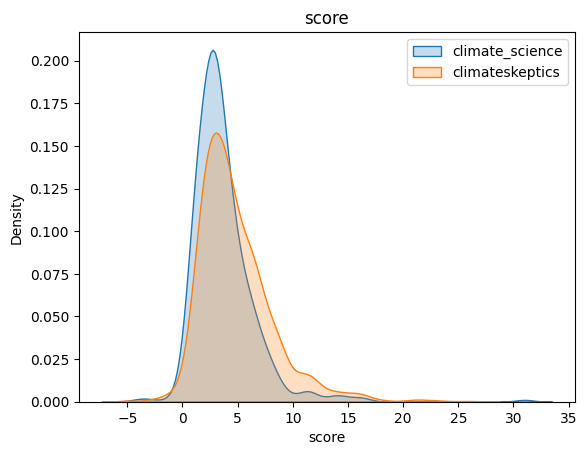

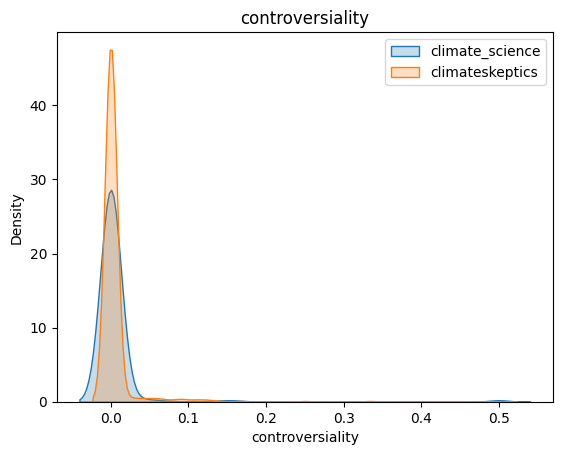

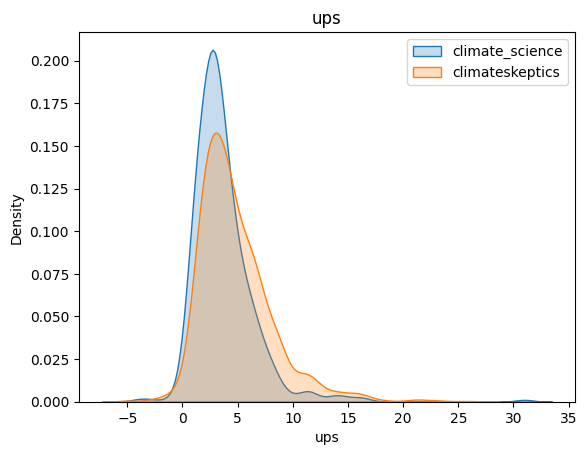

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


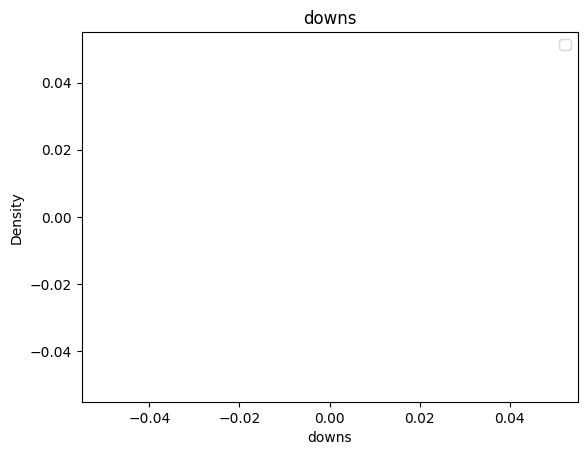

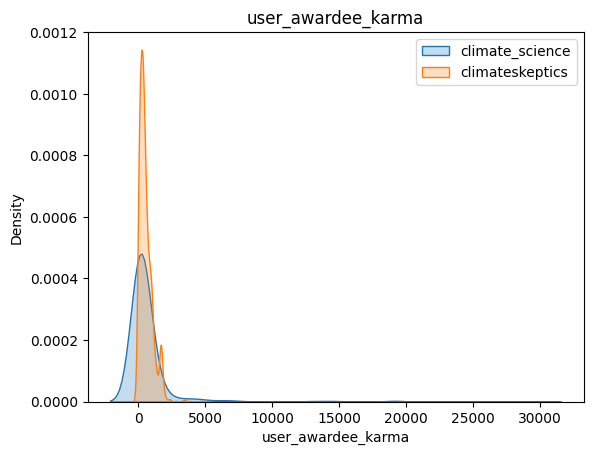

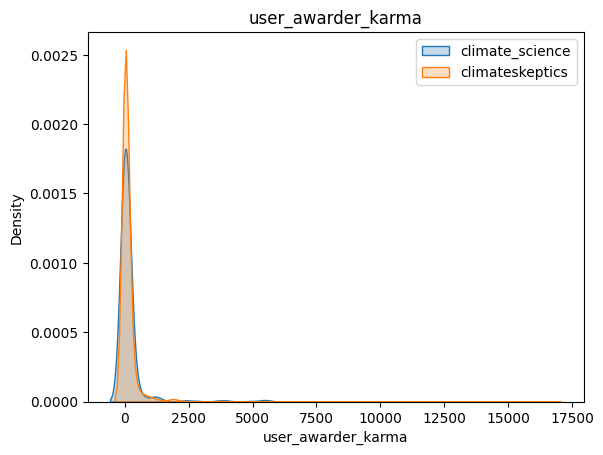

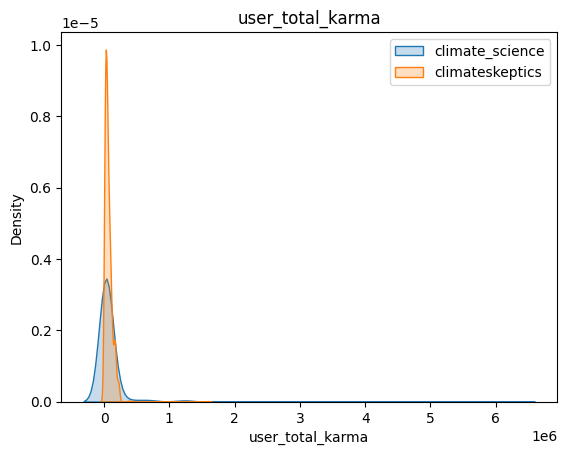

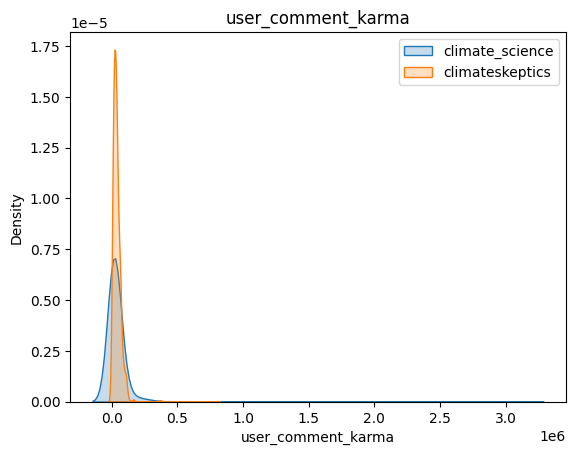

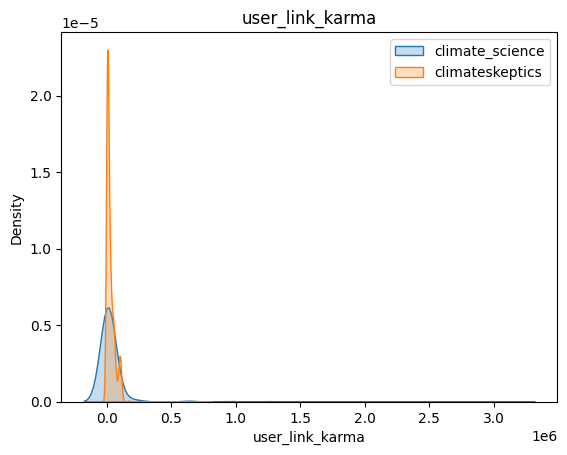

In [11]:
df_sci = grouped.get_group("climate_science")
df_skep = grouped.get_group("climateskeptics")

for feature in quants:
    sns.kdeplot(df_sci[feature], label="climate_science", shade=True)
    sns.kdeplot(df_skep[feature], label="climateskeptics", shade=True)
    plt.title(feature)
    plt.legend()
    plt.show()


### Statistical Testing

In [31]:
#t-test
stat_test_results = {}
for feature in quants:
    #remove nan values but do not modify the original dataframe
    sci = df_sci[feature].dropna()
    skep = df_skep[feature].dropna()
    if feature == "down":
        continue
    if feature == "score" or feature == "ups": #use t-test
        test = ttest_ind(sci, skep, equal_var=False)
    else: #use mann-whitney
        test = mannwhitneyu(sci, skep)
    
    stat_test_results[feature] = test
    
print(stat_test_results)
#build a dataframe to display the results
stat_test_df = pd.DataFrame(stat_test_results, index=["statistic", "p-value"]).T
print(stat_test_df)
stat_test_df["significant"] = stat_test_df["p-value"] < 0.05
stat_test_df["significant"] = stat_test_df["significant"].map({True: "Yes", False: "No"})
stat_test_df["statistic"] = stat_test_df["statistic"].round(3)
stat_test_df["p-value"] = stat_test_df["p-value"].round(3)
#add a column indicate which test was used
stat_test_df["test"] = ["t-test" if feature in ["score", "ups"] else "mann-whitney" for feature in quants]
#move it to the first column
stat_test_df.insert(0, 'test', stat_test_df.pop("test"))

stat_test_df

#Style and save the dataframe
styled_stat_test_df = stat_test_df.style.set_caption("Statistical Test Results") \
                                       .set_table_styles([
                                           {'selector': 'th', 'props': [('border', '1px solid black'), 
                                                                        ('padding', '10px'), 
                                                                        ('text-align', 'center'),
                                                                        ]},
                                           {'selector': 'td', 'props': [('border', '1px solid black'), 
                                                                        ('padding', '10px'), 
                                                                        ('text-align', 'center'),
                                                                        ]},
                                       ])
                                       
styled_stat_test_df.to_html("stat_test_results.html")
styled_stat_test_df


{'score': Ttest_indResult(statistic=-7.231013600960234, pvalue=1.0853354570110612e-12), 'controversiality': MannwhitneyuResult(statistic=341908.0, pvalue=0.051861227376005244), 'ups': Ttest_indResult(statistic=-7.231013600960234, pvalue=1.0853354570110612e-12), 'downs': MannwhitneyuResult(statistic=350285.0, pvalue=1.0), 'user_awardee_karma': MannwhitneyuResult(statistic=232169.0, pvalue=4.008301436031417e-27), 'user_awarder_karma': MannwhitneyuResult(statistic=318858.0, pvalue=0.004688839495166912), 'user_total_karma': MannwhitneyuResult(statistic=244960.5, pvalue=7.593894215110759e-22), 'user_comment_karma': MannwhitneyuResult(statistic=244151.0, pvalue=3.6700393999535772e-22), 'user_link_karma': MannwhitneyuResult(statistic=258595.5, pvalue=6.904055228232861e-17)}
                        statistic       p-value
score                   -7.231014  1.085335e-12
controversiality    341908.000000  5.186123e-02
ups                     -7.231014  1.085335e-12
downs               350285.000

,test,statistic,p-value,significant
score,t-test,-7.231000,0.000000,Yes
controversiality,mann-whitney,341908.000000,0.052000,No
ups,t-test,-7.231000,0.000000,Yes
downs,mann-whitney,350285.000000,1.000000,No
user_awardee_karma,mann-whitney,232169.000000,0.000000,Yes
user_awarder_karma,mann-whitney,318858.000000,0.005000,Yes
user_total_karma,mann-whitney,244960.500000,0.000000,Yes
user_comment_karma,mann-whitney,244151.000000,0.000000,Yes
user_link_karma,mann-whitney,258595.500000,0.000000,Yes


### Feature Engineer Datatime

In [32]:
df_sci["post_created_time"] = pd.to_datetime(df_sci["post_created_time"])
df_skep["post_created_time"] = pd.to_datetime(df_skep["post_created_time"])

dt_features = ["post_day", "post_month", "post_year", "post_day_of_week", "post_day_of_year", "post_hour"]


0    2018-09-18 03:59:40
16   2019-12-31 22:00:25
18   2019-07-04 22:47:26
21   2020-02-12 04:31:10
23   2020-01-06 14:35:49
Name: post_created_time, dtype: datetime64[ns]

In [33]:
df_sci["post_day"] = df_sci["post_created_time"].dt.day
df_sci["post_month"] = df_sci["post_created_time"].dt.month
df_sci["post_year"] = df_sci["post_created_time"].dt.year
df_sci["post_day_of_week"] = df_sci["post_created_time"].dt.dayofweek
df_sci["post_day_of_year"] = df_sci["post_created_time"].dt.dayofyear
df_sci["post_hour"] = df_sci["post_created_time"].dt.hour

df_skep["post_day"] = df_skep["post_created_time"].dt.day
df_skep["post_month"] = df_skep["post_created_time"].dt.month
df_skep["post_year"] = df_skep["post_created_time"].dt.year
df_skep["post_day_of_week"] = df_skep["post_created_time"].dt.dayofweek
df_skep["post_day_of_year"] = df_skep["post_created_time"].dt.dayofyear
df_skep["post_hour"] = df_skep["post_created_time"].dt.hour

In [34]:
df_sci = df_sci.sort_values(by='post_created_time')
df_skep = df_skep.sort_values(by='post_created_time')

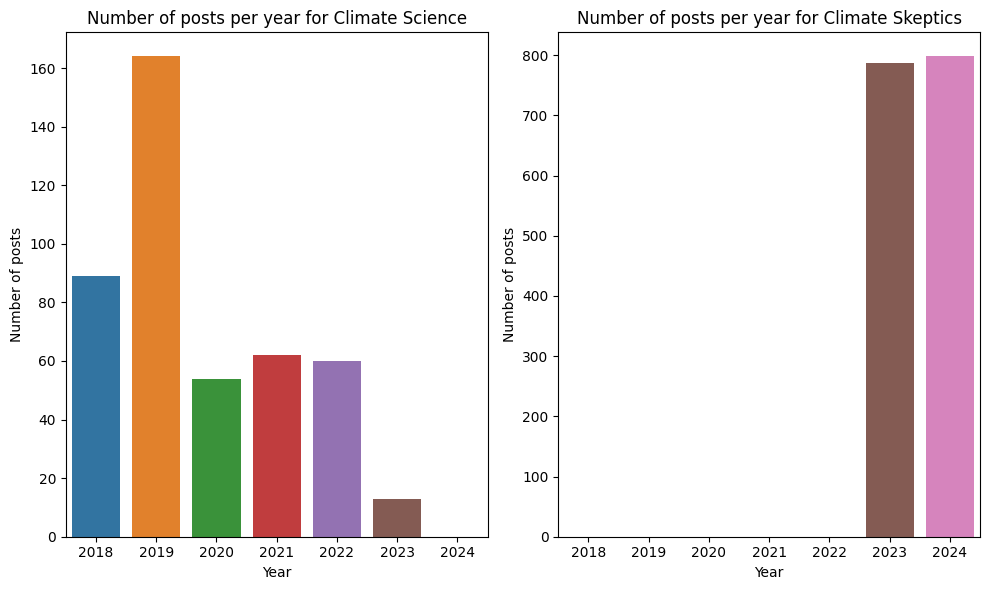

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
sns.countplot(data=df_sci, x='post_year', ax=ax[0], order=range(2018, 2025))
sns.countplot(data=df_skep, x='post_year', ax=ax[1], order=range(2018, 2025))
ax[0].set_title('Number of posts per year for Climate Science')
ax[1].set_title('Number of posts per year for Climate Skeptics')
ax[0].set_xlabel('Year')
ax[1].set_xlabel('Year')
ax[0].set_ylabel('Number of posts')
ax[1].set_ylabel('Number of posts')
plt.tight_layout()
plt.show()


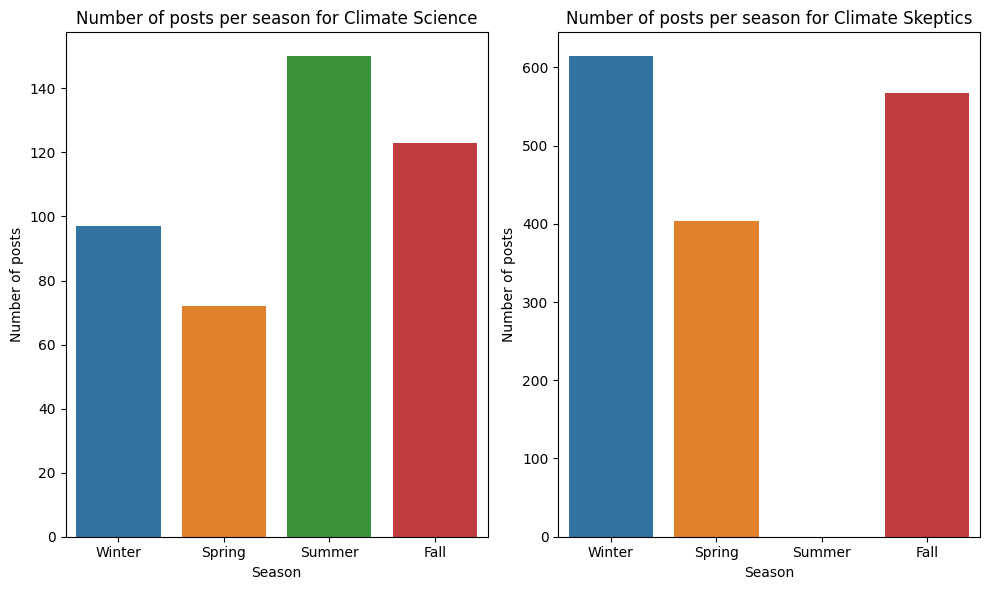

In [47]:
df_sci["season"] = df_sci["post_month"].map({1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall", 12: "Winter"})
df_skep["season"] = df_skep["post_month"].map({1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall", 12: "Winter"})
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
sns.countplot(data=df_sci, x='season', ax=ax[0], order=["Winter", "Spring", "Summer", "Fall"])
sns.countplot(data=df_skep, x='season', ax=ax[1], order=["Winter", "Spring", "Summer", "Fall"])
ax[0].set_title('Number of posts per season for Climate Science')
ax[1].set_title('Number of posts per season for Climate Skeptics')
ax[0].set_xlabel('Season')
ax[1].set_xlabel('Season')
ax[0].set_ylabel('Number of posts')
ax[1].set_ylabel('Number of posts')
plt.tight_layout()
plt.show()

In [55]:
#apply to the original dataframe
df["post_created_time"] = pd.to_datetime(df["post_created_time"])
df["post_day"] = df["post_created_time"].dt.day
df["post_month"] = df["post_created_time"].dt.month
df["post_year"] = df["post_created_time"].dt.year
df["post_day_of_week"] = df["post_created_time"].dt.dayofweek
df["post_day_of_year"] = df["post_created_time"].dt.dayofyear
df["post_hour"] = df["post_created_time"].dt.hour
df["season"] = df["post_month"].map({1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall", 12: "Winter"})


In [61]:
#Chi-square test
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["subreddit"], df["season"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square test result: for season")
print("Chi2: ", chi2)
print("p-value: ", p)
print("Degree of freedom: ", dof)
print()
contingency_table = pd.crosstab(df["subreddit"], df["post_year"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square test result: for post year")
print("Chi2: ", chi2)
print("p-value: ", p)
print("Degree of freedom: ", dof)


Chi-square test result: for season
Chi2:  584.54515023556
p-value:  2.2579980953331532e-126
Degree of freedom:  3

Chi-square test result: for post year
Chi2:  1951.9960632074597
p-value:  0.0
Degree of freedom:  6


### Data augmentation

In [153]:
#data augmentation for climate_science subreddit 
import nlpaug 
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.sentence as nas

def augment(text):
    #apply random word substitution
    for i in range(2):
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
        text = aug.augment(text)
   
    # apply insertion 
    for i in range(2):
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert")
        text = aug.augment(text)
    
    return text



In [155]:
#for each climate science post, apply the augmentation function
#create an empty df that has the same columns as the original dataframe
# augmented_df = pd.DataFrame(columns=df.columns)
# n = len(df_sci)
# cnt = 0
# # iterate over the rows of the dataframe
# for i, row in df.iterrows():
#     if row["subreddit"] == "climate_science":
#         text = row["self_text"]
#         #apply augmentation
#         augmented_text = augment(text) 
#         #append the original row to the new dataframe with self_text replaced by augmented_text
#         row["self_text"] = augmented_text
#         augmented_df = augmented_df.append(row)
#         cnt += 1
#         print(f"Augmented {cnt} out of {n} rows")

# new_df = pd.concat([df, augmented_df], ignore_index=True)
# new_df.to_pickle("project8_augmented.pkl")

        

Augmented 1 out of 442 rows
Augmented 2 out of 442 rows
Augmented 3 out of 442 rows
Augmented 4 out of 442 rows
Augmented 5 out of 442 rows
Augmented 6 out of 442 rows
Augmented 7 out of 442 rows
Augmented 8 out of 442 rows
Augmented 9 out of 442 rows
Augmented 10 out of 442 rows
Augmented 11 out of 442 rows
Augmented 12 out of 442 rows
Augmented 13 out of 442 rows
Augmented 14 out of 442 rows
Augmented 15 out of 442 rows
Augmented 16 out of 442 rows
Augmented 17 out of 442 rows
Augmented 18 out of 442 rows
Augmented 19 out of 442 rows
Augmented 20 out of 442 rows
Augmented 21 out of 442 rows
Augmented 22 out of 442 rows
Augmented 23 out of 442 rows
Augmented 24 out of 442 rows
Augmented 25 out of 442 rows
Augmented 26 out of 442 rows
Augmented 27 out of 442 rows
Augmented 28 out of 442 rows
Augmented 29 out of 442 rows
Augmented 30 out of 442 rows
Augmented 31 out of 442 rows
Augmented 32 out of 442 rows
Augmented 33 out of 442 rows
Augmented 34 out of 442 rows
Augmented 35 out of 442

,Unnamed: 0,post_id,self_text,user_is_verified,controversiality,ups,downs,subreddit,score,user_awardee_karma,...,post_thumbs_up,post_total_awards_ratio,post_created_time,post_day,post_month,post_year,post_day_of_week,post_day_of_year,post_hour,season
0,1979,9grgvl,"[yes, modeling using it with less detail is ea...",True True True True True True True,0.142857,2.857143,0,climate_science,2.857143,8.571429,...,33,0,2018-09-18 03:59:40,18,9,2018,1,261,3,Fall
16,1773,ei9ii6,[our atmosphere is a complex system. according...,True True True True True True,0.000000,3.500000,0,climate_science,3.500000,243.666667,...,18,0,2019-12-31 22:00:25,31,12,2019,1,365,22,Winter
18,1871,c98qmw,"[just see a robinson ' bush s, qualified only ...",True,0.000000,1.000000,0,climate_science,1.000000,1414.000000,...,33,0,2019-07-04 22:47:26,4,7,2019,3,185,22,Summer
21,1753,f2lj9c,[2013 even if nobody cheats : & w gt ; 2018 we...,True,0.000000,4.000000,0,climate_science,4.000000,6427.000000,...,14,0,2020-02-12 04:31:10,12,2,2020,2,43,4,Winter
23,1772,ekuwuq,[although may always exists any possible other...,True,0.000000,1.000000,0,climate_science,1.000000,461.000000,...,45,0,2020-01-06 14:35:49,6,1,2020,0,6,14,Winter


In [172]:
df = pkl.load(open('project8_augmented.pkl', 'rb'))
grouped = df.groupby("subreddit")
grouped.size()

subreddit
climate_science     884
climateskeptics    1585
dtype: int64

### Preprocessing Data

In [181]:
df["preprocessed_text"] = df["self_text"].apply(lambda x: x.lower())
stop_words = set(stopwords.words('english'))
df["tokenized_text"] = df["preprocessed_text"].apply(lambda x: word_tokenize(x))
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in stop_words])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word.isalnum()]) 
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if len(word) > 1]) # remove single character words, this can help with removing punctuation. 
lemmitizer = WordNetLemmatizer()
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [lemmitizer.lemmatize(word) for word in x])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if len(word) > 1]) # remove single character words, this can help with removing punctuation. 
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word.isalnum()]) 



In [182]:
df_cli_sci = grouped.get_group('climate_science')
df_cli_skp = grouped.get_group('climateskeptics')

print(df_cli_sci.shape)
print(df_cli_skp.shape)

(884, 28)
(1585, 28)


### Word Clouds

In [183]:
cli_sci_words = [word for words in df_cli_sci["tokenized_text"].values for word in words]
cli_skp_words = [word for words in df_cli_skp["tokenized_text"].values for word in words]

In [184]:
common_words = set()
with open ("common_words.txt", "r") as f:
    for line in f:
        common_words.add(line.strip())
        
print(len(common_words))
cli_sci_words = [word for word in cli_sci_words if word not in common_words]
cli_skp_words = [word for word in cli_skp_words if word not in common_words]

63


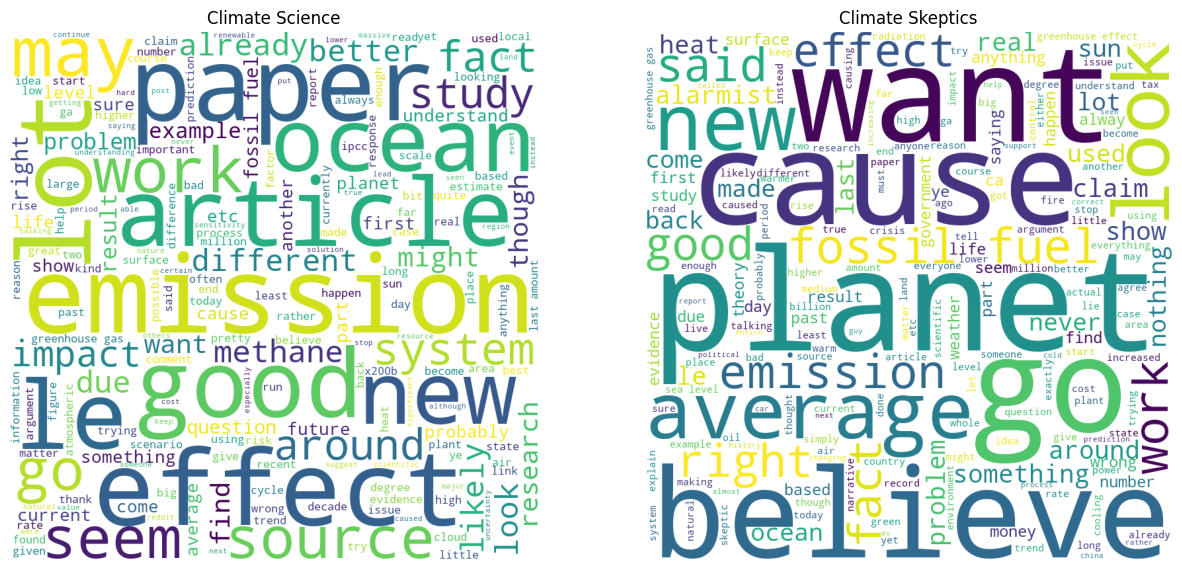

In [185]:
#word cloud for climate science and climate skeptics in subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 15))

wordcloud_cli_sci = WordCloud(width=800, height=800, background_color='white').generate(' '.join(cli_sci_words))
ax[0].imshow(wordcloud_cli_sci)
ax[0].axis('off')
ax[0].set_title('Climate Science')

wordcloud_cli_skp = WordCloud(width=800, height=800, background_color='white').generate(' '.join(cli_skp_words))
ax[1].imshow(wordcloud_cli_skp)
ax[1].axis('off')
ax[1].set_title('Climate Skeptics')

plt.show()

In [186]:
#after we have made a list of common words, we can remove them from the tokenized text
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in common_words])
df["preprocessed_text"] = df["tokenized_text"].apply(lambda x: ' '.join(x)) # convert back to string, now each observation is a string of words that has been cleaned

### TF-IDF

In [188]:
 #initialize the vectorizer without any preprocessing
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df["preprocessed_text"]) #fitting and transforming the vectorizer on the preprocessed text 
tfidf_matrix = tfidf_matrix.toarray() #convert object matrix to a matrix
print(tfidf_matrix.shape) 
df["tfidf_vector"] = [vector for vector in tfidf_matrix] #store the vectors in the dataframe for later use

(2469, 28663)


In [190]:
most_prominent_words = ['emission', 'source', 'planet', 'believe']
#find the indices of the most prominent words in the tfidf features 
word_indices = [tfidf_vectorizer.vocabulary_[word] for word in most_prominent_words]
#find the cosine similarity between the most prominent words
cosine_similarities = cosine_similarity(tfidf_matrix[:, word_indices].T)
#store the cosine similarities in a dataframe
cosine_similarities_df = pd.DataFrame(cosine_similarities, columns=most_prominent_words, index=most_prominent_words)
print(cosine_similarities_df)

          emission    source    planet   believe
emission  1.000000  0.237614  0.189858  0.103832
source    0.237614  1.000000  0.141918  0.162311
planet    0.189858  0.141918  1.000000  0.225584
believe   0.103832  0.162311  0.225584  1.000000


### ML models with TF-IDF

In [204]:
X = tfidf_matrix
y = df["subreddit"].values
y = np.array([0 if subreddit == 'climate_science' else 1 for subreddit in y]) #convert the subreddit names to binary values
print(X.shape)
print(y.shape)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

(2469, 28663)
(2469,)


In [205]:
def train_and_test(model, X_train, X_test, y_train, y_test):
    time_start = time.time()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1 = precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)
    
    time_elapsed = round((time.time() - time_start),3)
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'time_elapsed(s)': time_elapsed}

In [206]:
classifiers = [
    ("Logistic Regression", LogisticRegression()), 
    ("Random Forest", RandomForestClassifier()), 
    ("Naive Bayes", GaussianNB()), 
    ("SVM", SVC())
]
results = {}

for classifier in classifiers:
    name, model = classifier
    results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.864372,0.837333,0.981250,0.903597,0.580
Random Forest,0.894737,0.876404,0.975000,0.923077,8.016
Naive Bayes,0.900810,0.904478,0.946875,0.925191,0.671
SVM,0.906883,0.882682,0.987500,0.932153,59.518


In [208]:
def select_k(k):
    selector = SelectKBest(chi2, k=k)
    selected_indices = selector.fit(X, y).get_support(indices=True) #get the indices of the selected features

    return selected_indices

#select top k features using tfidf
def select_k_tfidf(k):
    #sum the tfidf scores for each word
    word_scores = np.sum(tfidf_matrix, axis=0)
    #get the indices of the top k words
    top_k_indices = np.argsort(word_scores)[-k:] #sort the indices in ascending order and get the last k indices
     
    return top_k_indices

In [220]:
k_s = [25000, 20000, 15000, 10000, 5000]
pruned_results = {} 
for k in k_s:
    select_indices = select_k(k)
    X_train_k = X_train[:, select_indices]
    X_test_k = X_test[:, select_indices]
    pruned_results[f'RandomForest_{k}'] = train_and_test(RandomForestClassifier(), X_train_k, X_test_k, y_train, y_test)
    
pruned_results_df = pd.DataFrame(pruned_results).T
pruned_results_df

,accuracy,precision,recall,f1,time_elapsed(s)
RandomForest_25000,0.902834,0.877778,0.987500,0.929412,3.644
RandomForest_20000,0.906883,0.880556,0.990625,0.932353,3.184
RandomForest_15000,0.898785,0.875000,0.984375,0.926471,2.639
RandomForest_10000,0.906883,0.891429,0.975000,0.931343,2.075
RandomForest_5000,0.908907,0.887324,0.984375,0.933333,1.423


### Metadata

In [221]:
df['summer'] = df['season'].apply(lambda x: 1 if x == 'Summer' else 0)
df['winter'] = df['season'].apply(lambda x: 1 if x == 'Winter' else 0)
df['spring'] = df['season'].apply(lambda x: 1 if x == 'Spring' else 0)
df['fall'] = df['season'].apply(lambda x: 1 if x == 'Fall' else 0)

optimal_k = 5000  
select_indices = select_k(optimal_k) #select the optimal k features
X_pruned = X[:, select_indices] #select the optimal k features from the original matrix
metadata_features = [   "score", 
                        "user_awardee_karma", 
                        "user_awarder_karma", 
                        "user_total_karma", 
                        "user_comment_karma", 
                        "user_link_karma",
                        "summer",
                        "fall",
                        "winter",
                        "spring",  
                        "post_year" 
                     ]

metadata_matrix = df[metadata_features].values
metadata_matrix = preprocessing.StandardScaler().fit_transform(metadata_matrix) # the metadata matrix is standardized

print(metadata_matrix.shape)
print(np.isnan(metadata_matrix).any())



(2469, 11)
True


In [222]:
X_augmented = np.concatenate((X_pruned, metadata_matrix), axis=1) #concatenate the pruned features with the metadata features
print(X_augmented.shape)
rows_with_nan = np.isnan(X_augmented).any(axis=1) #check if there are any rows with NaN values
X_augmented = X_augmented[~rows_with_nan] #remove the rows with NaN values
y_augmented = y[~rows_with_nan] #remove the corresponding labels
print(X_augmented.shape)

(2469, 5011)
(2464, 5011)


In [224]:
X_train_augmented, X_test_augmented, y_train_augmented, y_test_augmented = train_test_split(X_augmented, y_augmented, test_size=0.2)
augmented_results = {}

for classifier in classifiers:
    name, model = classifier
    augmented_results[name] = train_and_test(model, X_train_augmented, X_test_augmented, y_train_augmented, y_test_augmented)
    
augmented_results_df = pd.DataFrame(augmented_results).T
augmented_results_df


,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.997972,0.996835,1.000000,0.998415,0.085
Random Forest,0.997972,0.996835,1.000000,0.998415,1.258
Naive Bayes,0.975659,0.974922,0.987302,0.981073,0.118
SVM,0.993915,0.990566,1.000000,0.995261,2.441


In [227]:
#output top 5000 words to a file 
# top_k_indices = set(select_k_tfidf(5000))
# top_words = [word for word, idx in tfidf_vectorizer.vocabulary_.items() if idx in top_k_indices]

# with open("top_5000.txt", "w") as f:
#     for word in top_words:
#         f.write(word + "\n")



### Word2Vec ML models

In [229]:
top_5000_words = set()
with open("top_5000.txt", "r") as f:
    for line in f:
        top_5000_words.add(line.strip())
        
df["preprocessed_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word in top_5000_words])

In [225]:
import gensim.downloader as api
word2vec_model = api.load('word2vec-google-news-300')

In [230]:
most_prominent_words = ['emission', 'source', 'planet', 'believe']
cosine_similarities = cosine_similarity(word2vec_model[most_prominent_words])

cos_sim_df = pd.DataFrame(cosine_similarities, columns=most_prominent_words, index=most_prominent_words)
cos_sim_df

,emission,source,planet,believe
emission,1.000000,0.050124,0.215118,0.022043
source,0.050124,1.000000,0.107579,0.044794
planet,0.215118,0.107579,1.000000,0.084979
believe,0.022043,0.044794,0.084979,1.000000


In [243]:
df["avg_sentence_vector"] = df["preprocessed_text"].apply(lambda x: np.mean([word2vec_model[word] for word in x if word in word2vec_model.key_to_index], axis=0))

#check the dimension of the average sentence vector of each post
df["avg_sentence_vector"].apply(lambda x: x.shape).value_counts()
df = df.dropna(subset=["avg_sentence_vector"])
print(df.shape)

(2462, 35)


In [235]:
X = np.array(df["avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [236]:
classifiers = [
    ("Logistic Regression", LogisticRegression()), 
    ("Random Forest", RandomForestClassifier()), 
    ("Naive Bayes", GaussianNB()), 
    ("SVM", SVC())
]
results = {}

for classifier in classifiers:
    name, model = classifier
    results[name] = train_and_test(model, X_train, X_test, y_train, y_test)

results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.829615,0.858156,0.654054,0.742331,0.017
Random Forest,0.845842,0.860927,0.702703,0.773810,1.546
Naive Bayes,0.645030,0.518939,0.740541,0.610245,0.008
SVM,0.870183,0.875776,0.762162,0.815029,0.172


In [245]:
tfidf = TfidfVectorizer()
documents = df["preprocessed_text"].apply(lambda x: ' '.join(x))
tf_idf_matrix = tfidf.fit_transform(documents)

def compute_tfidf_avg_vector(doc_index, words):
    vectors = []
    for word in words:
        if word in word2vec_model.key_to_index and word in tfidf.vocabulary_:
            tfidf_weight = tf_idf_matrix[doc_index, tfidf.vocabulary_[word]]
            word_vector = word2vec_model[word]
            vectors.append(tfidf_weight * word_vector)
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return None

df["tfidf_avg_sentence_vector"] = [compute_tfidf_avg_vector(i, words) for i, words in enumerate(df["preprocessed_text"])]

#remove rows with NaN values
df = df.dropna(subset=["tfidf_avg_sentence_vector"])
df.shape

(2462, 35)

In [239]:
X = np.array(df["tfidf_avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tfidf_results = {}

for classifier in classifiers:
    name, model = classifier
    tfidf_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
tfidf_results_df = pd.DataFrame(tfidf_results).T
tfidf_results_df

,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.661258,0.800000,0.023529,0.045714,0.015
Random Forest,0.866126,0.876812,0.711765,0.785714,1.495
Naive Bayes,0.383367,0.340476,0.841176,0.484746,0.008
SVM,0.833671,0.828358,0.652941,0.730263,0.223


In [ ]:
#create metadata features
metadata_matrix = df[metadata_features].values
metadata_matrix = preprocessing.StandardScaler().fit_transform(metadata_matrix) # the metadata matrix is standardized

In [242]:
X = df["avg_sentence_vector"].values.tolist()
X = np.concatenate([X, metadata_matrix], axis=1)
y = df["subreddit"].apply(lambda x: 1 if x == "climate_science" else 0)

#delete rows with NaN values in X and y
nan_indices = np.isnan(X).any(axis=1)
X = X[~nan_indices]
y = y[~nan_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

metadata_results = {}

for classifier in classifiers:
    name, model = classifier
    metadata_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
metadata_results_df = pd.DataFrame(metadata_results).T


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 2462 and the array at index 1 has size 2469